In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

import sys
sys.path.append('../scripts')
from functions import *


/tmp/ipykernel_1294251/2105548500.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(patch_ids))  # up to 20 distinct colors; use 'nipy_spectral' or similar if >20 patches


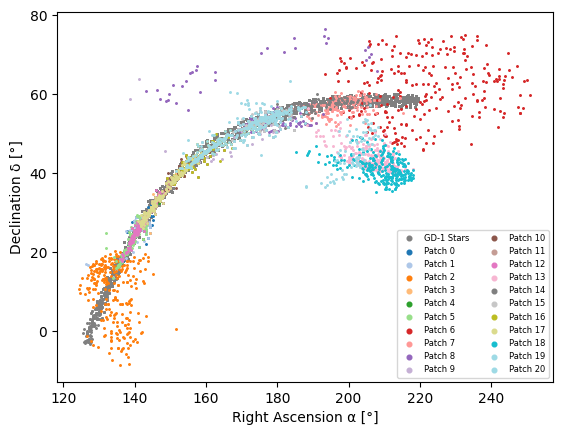

In [26]:
gd1_stars = []
for idx in range(21):
  df_test = pd.read_hdf(f'../results/patch_{idx}/rotpmdec/training/df_test.h5')
  gd1 = df_test[df_test['stream']==True]
  gd1_stars.append(gd1)

gd1_stars = pd.concat([df for df in gd1_stars])
gd1_stars['ra_wrapped'] = gd1_stars['ra'].apply(lambda x: x if x > 100 else x + 360)


top_stars = pd.read_hdf('../results/fullgd1/rotpmdec/raw/all_top_stars.h5')

plt.figure()

plt.scatter(gd1_stars['ra_wrapped'], gd1_stars['dec'], label='GD-1 Stars',
            color='grey', marker='.', s=5)

# color code top_stars by patch_id
patch_ids = np.sort(top_stars['patch'].unique())
cmap = cm.get_cmap('tab20', len(patch_ids))  # up to 20 distinct colors; use 'nipy_spectral' or similar if >20 patches

for i, pid in enumerate(patch_ids):
    patch_data = top_stars[top_stars['patch'] == pid]
    plt.scatter(patch_data['ra_wrapped'], patch_data['dec'],
                color=cmap(i), marker='.', s=5, label=f'Patch {pid}')

plt.xlabel('Right Ascension α [°]', fontsize=10)
plt.ylabel('Declination δ [°]', fontsize=10)
plt.legend(fontsize=6, ncol=2, loc='lower right', markerscale=3)
plt.show()

In [3]:
# load promising stars from the paper

paper_promising_stars = pd.read_hdf('../paper_promising_stars.h5')
paper_promising_stars.columns = ['patch', 'ra_wrapped', 'dec', 'rotpmra', 'rotpmdec', 'b-r', 'g', '5d_distance', 'nn_score']
paper_promising_stars.head()

,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score
0,3,153.343750,37.944386,-3.648079,-11.087369,0.585669,18.889666,0.199219,0.760671
1,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.161793,0.710143
2,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.200405,0.703576
3,3,145.067444,34.774712,-3.889829,-11.528839,0.560968,18.343340,0.208592,0.687666
4,0,144.668640,29.123871,-3.294825,-9.761044,0.698603,18.599613,0.157535,0.628063


In [4]:
# load promising stars from rotpmdec run

dec_promising_stars = pd.read_hdf('../results/fullgd1/rotpmdec/promising/promising_stars.h5')
dec_promising_stars = dec_promising_stars[['patch', 'ra_wrapped', 'dec', 'rotpmra', 'rotpmdec', 'b-r', 'g', '5d_distance', 'nn_score']]
dec_promising_stars.head()

,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score
0,3,145.769653,29.695894,-5.139831,-10.660382,0.628374,19.351206,0.193660,0.723562
1,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.181132,0.673470
2,3,150.878479,38.054474,-4.654859,-12.773977,0.679430,19.203457,0.193093,0.651464
3,0,144.668640,29.123871,-3.294825,-9.761044,0.698603,18.599613,0.138245,0.650352
4,3,145.067444,34.774712,-3.889829,-11.528839,0.560968,18.343340,0.195038,0.645145


In [5]:
# compare rotpmdec run with original paper for duplicates

# create new data frame with duplicate potential stars between paper and new run

paper_promising_stars['source'] = 'og_paper'
dec_promising_stars['source'] = 'new_dec'

dup_df_rows = []
for _, og_row in paper_promising_stars.iterrows():
    og_dec = og_row['dec']
    for _, dup_row in dec_promising_stars.iterrows():
        if dup_row['dec'] == og_dec:
            dup_df_rows.append(og_row)
            dup_df_rows.append(dup_row)
        else:
            continue

dup_df = pd.DataFrame(dup_df_rows).reset_index(drop=True)
print(len(dup_df))
dup_df.head(10)

64


,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score,source
0,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.161793,0.710143,og_paper
1,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.135485,0.644466,new_dec
2,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.200405,0.703576,og_paper
3,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.181132,0.673470,new_dec
4,3,145.067444,34.774712,-3.889829,-11.528839,0.560968,18.343340,0.208592,0.687666,og_paper
5,3,145.067444,34.774712,-3.889829,-11.528839,0.560968,18.343340,0.195038,0.645145,new_dec
6,0,144.668640,29.123871,-3.294825,-9.761044,0.698603,18.599613,0.157535,0.628063,og_paper
7,0,144.668640,29.123871,-3.294825,-9.761044,0.698603,18.599613,0.138245,0.650352,new_dec
8,0,139.284058,27.534752,-2.474001,-11.759004,0.678160,18.488266,0.202521,0.608509,og_paper
9,0,139.284058,27.534752,-2.474001,-11.759004,0.678160,18.488266,0.184629,0.554853,new_dec


In [6]:
# load promising stars from rotpmra run

ra_promising_stars = pd.read_hdf('../results/fullgd1/rotpmra/promising/promising_stars.h5')
ra_promising_stars = ra_promising_stars[['patch', 'ra_wrapped', 'dec', 'rotpmra', 'rotpmdec', 'b-r', 'g', '5d_distance', 'nn_score']]
ra_promising_stars.head()

,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score
0,3,150.559784,36.831982,-2.201846,-13.133117,0.630327,18.824238,0.075047,0.720172
1,17,157.636017,43.823238,-6.345773,-10.317571,0.664040,19.623980,0.121868,0.701418
2,3,149.116791,38.697327,-4.249999,-12.975117,0.625946,19.047796,0.104371,0.679670
3,10,159.310638,44.860550,-5.905547,-11.129212,0.646944,18.803308,0.091881,0.666282
4,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.072054,0.656383


In [7]:
# compare rotpmra run with original paper for duplicates

paper_promising_stars['source'] = 'og_paper'
ra_promising_stars['source'] = 'new_ra'

dup_df_rows = []
for _, og_row in paper_promising_stars.iterrows():
    og_dec = og_row['dec']
    for _, dup_row in ra_promising_stars.iterrows():
        if dup_row['dec'] == og_dec:
            dup_df_rows.append(og_row)
            dup_df_rows.append(dup_row)
        else:
            continue

dup_df = pd.DataFrame(dup_df_rows).reset_index(drop=True)
print(len(dup_df))
dup_df.head(10)

32


,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score,source
0,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.161793,0.710143,og_paper
1,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.072054,0.656383,new_ra
2,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.200405,0.703576,og_paper
3,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.075025,0.626994,new_ra
4,0,137.850464,25.221642,-2.823553,-13.327346,0.713997,18.919308,0.181071,0.600161,og_paper
5,0,137.850464,25.221642,-2.823553,-13.327346,0.713997,18.919308,0.087301,0.546651,new_ra
6,10,159.375610,43.155155,-6.771805,-13.304443,0.577917,18.163719,0.193080,0.582036,og_paper
7,9,159.375610,43.155155,-7.932949,-12.646496,0.577917,18.163719,0.095828,0.427128,new_ra
8,10,152.977966,43.714725,-5.651521,-11.580858,0.640087,18.764666,0.173924,0.541810,og_paper
9,10,152.977966,43.714725,-5.651521,-11.580858,0.640087,18.764666,0.132942,0.551324,new_ra


In [8]:
dec_promising_stars['source'] = 'new_dec'
ra_promising_stars['source'] = 'new_ra'

dup_df_rows = []
for _, dec_row in dec_promising_stars.iterrows():
    new_dec = dec_row['dec']
    for _, ra_row in ra_promising_stars.iterrows():
        if ra_row['dec'] == new_dec:
            dup_df_rows.append(dec_row)
            dup_df_rows.append(ra_row)
        else:
            continue

dup_df = pd.DataFrame(dup_df_rows).reset_index(drop=True)
print(len(dup_df))
dup_df

30


,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score,source
0,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.181132,0.673470,new_dec
1,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.075025,0.626994,new_ra
2,3,150.878479,38.054474,-4.654859,-12.773977,0.679430,19.203457,0.193093,0.651464,new_dec
3,10,150.878479,38.054474,-6.129418,-12.135585,0.679430,19.203457,0.121945,0.605030,new_ra
4,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.135485,0.644466,new_dec
5,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.072054,0.656383,new_ra
6,0,137.850464,25.221642,-2.823553,-13.327346,0.713997,18.919308,0.173921,0.606846,new_dec
7,0,137.850464,25.221642,-2.823553,-13.327346,0.713997,18.919308,0.087301,0.546651,new_ra
8,10,152.977966,43.714725,-5.651521,-11.580858,0.640087,18.764666,0.170829,0.557602,new_dec
9,10,152.977966,43.714725,-5.651521,-11.580858,0.640087,18.764666,0.132942,0.551324,new_ra


In [9]:
promising_both = dup_df[dup_df['source'] == 'new_dec']

promising_all = []
for _, row_both in promising_both.iterrows():
    dec_both = row_both['dec']
    for _, row_paper in paper_promising_stars.iterrows():
        if row_paper['dec'] == dec_both:
            promising_all.append(row_paper)
        else:
            continue

promising_all = pd.DataFrame(promising_all).reset_index(drop=True)
print(len(promising_all))
promising_all


11


,patch,ra_wrapped,dec,rotpmra,rotpmdec,b-r,g,5d_distance,nn_score,source
0,3,147.581451,33.771442,-4.031364,-12.893708,0.692181,19.217056,0.200405,0.703576,og_paper
1,3,147.407532,34.807056,-4.174263,-13.030541,0.632448,18.280497,0.161793,0.710143,og_paper
2,0,137.850464,25.221642,-2.823553,-13.327346,0.713997,18.919308,0.181071,0.600161,og_paper
3,10,152.977966,43.714725,-5.651521,-11.580858,0.640087,18.764666,0.173924,0.541810,og_paper
4,9,159.310638,44.860550,-6.879270,-10.555117,0.646944,18.803308,0.209683,0.477115,og_paper
5,19,179.387024,53.861988,-7.553021,-9.258564,0.633465,18.817064,0.177797,0.484814,og_paper
6,9,165.833618,46.725655,-5.527166,-10.702893,0.613531,18.830116,0.150776,0.483593,og_paper
7,9,167.548462,46.377983,-6.176190,-11.992228,0.646498,19.345844,0.088779,0.497648,og_paper
8,9,163.159119,48.486298,-6.168635,-10.865490,0.666342,18.826414,0.182255,0.472844,og_paper
9,9,169.494263,48.418388,-6.111476,-10.342608,0.673502,19.317274,0.128495,0.484024,og_paper


[0.005994, 0.004592, 0.002316, 0.008973, 0.008108, 0.006269, 0.001075, 0.001851, 0.003283, 0.005026, 0.007226, 0.010369, 0.009459, 0.001809, 0.003495, 0.004419, 0.006246, 0.008843, 0.002151, 0.003581, 0.005055]
[0.772, 0.58, 0.0, 0.888, 0.836, 0.68, 0.0, 0.452, 0.428, 0.636, 0.768, 0.872, 0.852, 0.0, 0.668, 0.612, 0.7, 0.864, 0.0, 0.336, 0.712]


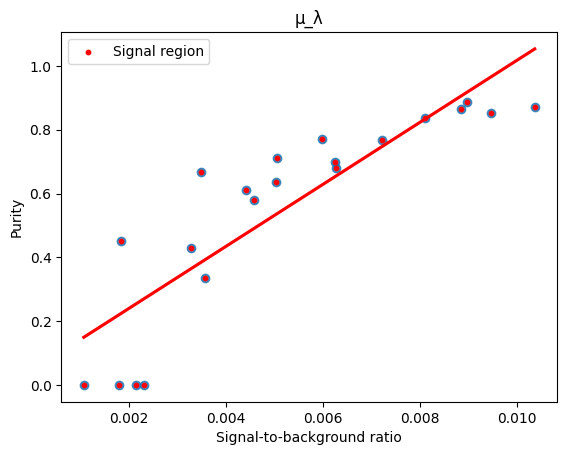

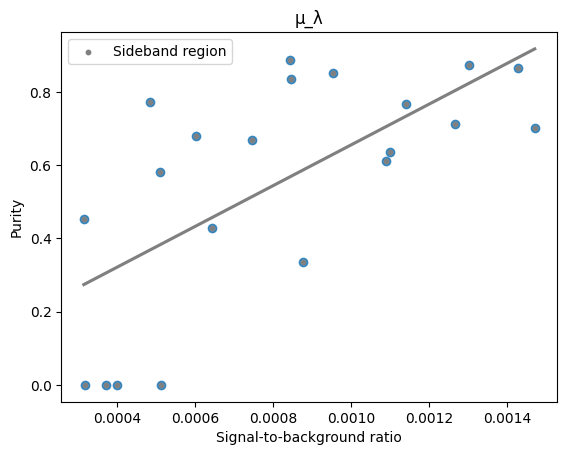

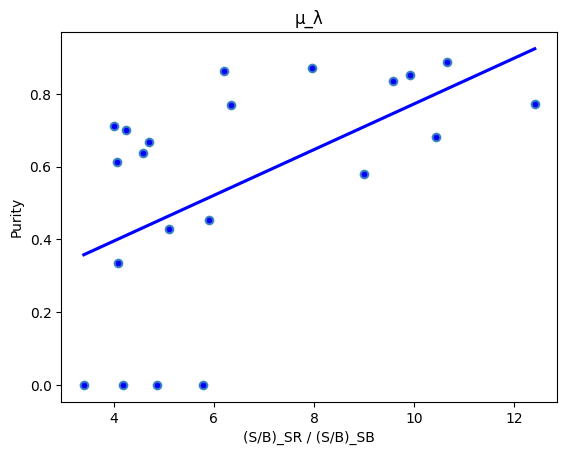

In [ ]:
scan_var = 'rotpmdec'

ratios_signal = []
ratios_sideband = []
purities = []

for idx in range(21):
  df_test = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/training/df_test.h5')

  df_signalreg = df_test[df_test['region_label']==1]
  df_signal_stream = df_signalreg[df_signalreg['stream']==True]
  df_signal_back = df_signalreg[df_signalreg['stream']==False]

  df_backgroundreg = df_test[df_test['region_label']==0]
  df_back_stream = df_backgroundreg[df_backgroundreg['stream']==True]
  df_back_back = df_backgroundreg[df_backgroundreg['stream']==False]

  ratio_signal = round(len(df_signal_stream)/len(df_signal_back), 6)
  ratios_signal.append(ratio_signal)
  ratio_sideband = round(len(df_back_stream)/len(df_back_back), 6)
  ratios_sideband.append(ratio_sideband)

  df_top = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/fid_cuts/df_top.h5')
  purity = len(df_top[df_top['stream']==True]) / len(df_top)
  purities.append(purity)

print(ratios_signal)
print(purities)

import seaborn as sns


# Create the scatter plot with a correlation line
sns.regplot(x=ratios_signal, y=purities, line_kws={"color": "red"}, ci=None)


plt.scatter(ratios_signal, purities, color='red', label='Signal region', s=10)
plt.xlabel('Signal-to-background ratio')
plt.ylabel('Purity')
plt.title('μ_λ')
plt.legend()
plt.show()


# sns.regplot(x=ratios_sideband, y=purities, line_kws={"color": "grey"}, ci=None)

# plt.scatter(ratios_sideband, purities, color='grey', label='Sideband region', s=10)
# plt.xlabel('Signal-to-background ratio')
# plt.ylabel('Purity')
# plt.title('μ_λ')
# plt.legend()
# plt.show()


ratios_ratio = np.array(ratios_signal) / np.array(ratios_sideband)

sns.regplot(x=ratios_ratio, y=purities, line_kws={"color": "blue"}, ci=None)

plt.scatter(ratios_ratio, purities, color='blue', s=10)
plt.xlabel('(S/B)_SR / (S/B)_SB')
plt.ylabel('Purity')
plt.title('μ_λ')
plt.show()

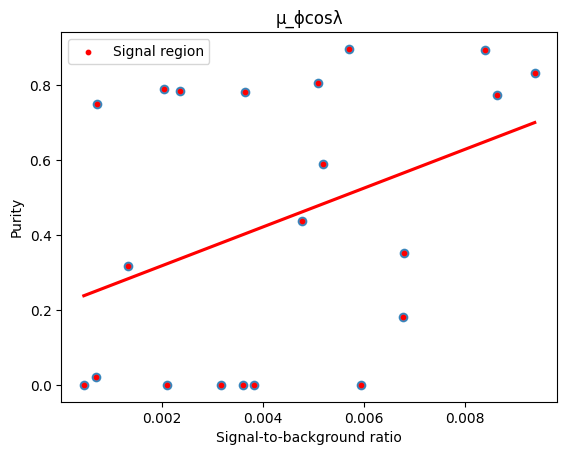

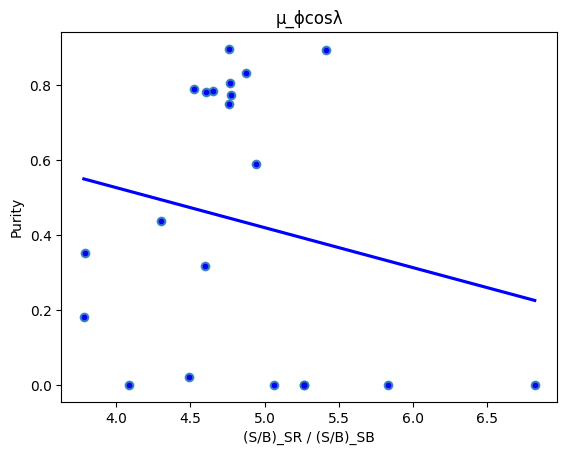

In [43]:
## same but for right ascension

scan_var = 'rotpmra'

ratios_signal = []
ratios_sideband = []
purities = []

for idx in range(21):
  df_test = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/training/df_test.h5')

  df_signalreg = df_test[df_test['region_label']==1]
  df_signal_stream = df_signalreg[df_signalreg['stream']==True]
  df_signal_back = df_signalreg[df_signalreg['stream']==False]

  df_backgroundreg = df_test[df_test['region_label']==0]
  df_back_stream = df_backgroundreg[df_backgroundreg['stream']==True]
  df_back_back = df_backgroundreg[df_backgroundreg['stream']==False]

  ratio_signal = round(len(df_signal_stream)/len(df_signal_back), 6)
  ratios_signal.append(ratio_signal)
  ratio_sideband = round(len(df_back_stream)/len(df_back_back), 6)
  ratios_sideband.append(ratio_sideband)

  df_top = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/fid_cuts/df_top.h5')
  purity = len(df_top[df_top['stream']==True]) / len(df_top)
  purities.append(purity)


sns.regplot(x=ratios_signal, y=purities, line_kws={"color": "red"}, ci=None)

plt.scatter(ratios_signal, purities, color='red', label='Signal region', s=10)
plt.xlabel('Signal-to-background ratio')
plt.ylabel('Purity')
plt.title('μ_ϕcosλ')
plt.legend()
plt.show()

# sns.regplot(x=ratios_sideband, y=purities, line_kws={"color": "grey"})

# plt.scatter(ratios_sideband, purities, color='grey', label='Sideband region', s=10)
# plt.xlabel('Signal-to-background ratio')
# plt.ylabel('Purity')
# plt.title('μ_ϕcosλ')
# plt.legend()
# plt.show()

ratios_ratio = np.array(ratios_signal) / np.array(ratios_sideband)
sns.regplot(x=ratios_ratio, y=purities, line_kws={"color": "blue"}, ci=None)

plt.scatter(ratios_ratio, purities, color='blue', s=10)
plt.xlabel('(S/B)_SR / (S/B)_SB')
plt.ylabel('Purity')
plt.title('μ_ϕcosλ')
plt.show()

In [3]:
scan_var = 'rotpmdec'

patches = []
vars = []
ratios_signal = []
ratios_sideband = []
purities = []

for idx in range(21):
  patches.append(idx)
  vars.append(scan_var)
  df_test = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/training/df_test.h5')

  df_signalreg = df_test[df_test['region_label']==1]
  df_signal_stream = df_signalreg[df_signalreg['stream']==True]
  df_signal_back = df_signalreg[df_signalreg['stream']==False]

  df_backgroundreg = df_test[df_test['region_label']==0]
  df_back_stream = df_backgroundreg[df_backgroundreg['stream']==True]
  df_back_back = df_backgroundreg[df_backgroundreg['stream']==False]

  ratio_signal = round(len(df_signal_stream)/len(df_signal_back), 6)
  ratios_signal.append(ratio_signal)
  ratio_sideband = round(len(df_back_stream)/len(df_back_back), 6)
  ratios_sideband.append(ratio_sideband)

  df_top = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/fid_cuts/df_top.h5')
  purity = len(df_top[df_top['stream']==True]) / len(df_top)
  purities.append(purity)

data_dec = pd.DataFrame({
  'patch': patches,
  'scan_var': vars,
  'purity': purities,
  'sr_ratio': ratios_signal,
  'sb_ratio': ratios_sideband})

In [4]:
scan_var = 'rotpmra'

patches = []
vars = []
ratios_signal = []
ratios_sideband = []
purities = []

for idx in range(21):
  patches.append(idx)
  vars.append(scan_var)
  df_test = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/training/df_test.h5')

  df_signalreg = df_test[df_test['region_label']==1]
  df_signal_stream = df_signalreg[df_signalreg['stream']==True]
  df_signal_back = df_signalreg[df_signalreg['stream']==False]

  df_backgroundreg = df_test[df_test['region_label']==0]
  df_back_stream = df_backgroundreg[df_backgroundreg['stream']==True]
  df_back_back = df_backgroundreg[df_backgroundreg['stream']==False]

  ratio_signal = round(len(df_signal_stream)/len(df_signal_back), 6)
  ratios_signal.append(ratio_signal)
  ratio_sideband = round(len(df_back_stream)/len(df_back_back), 6)
  ratios_sideband.append(ratio_sideband)

  df_top = pd.read_hdf(f'../results/patch_{idx}/{scan_var}/fid_cuts/df_top.h5')
  purity = len(df_top[df_top['stream']==True]) / len(df_top)
  purities.append(purity)

data_ra = pd.DataFrame({
  'patch': patches,
  'scan_var': vars,
  'purity': purities,
  'sr_ratio': ratios_signal,
  'sb_ratio': ratios_sideband})


data_ra.head()

,patch,scan_var,purity,sr_ratio,sb_ratio
0,0,rotpmra,0.748,0.000719,0.000151
1,1,rotpmra,0.020,0.000700,0.000156
2,2,rotpmra,0.000,0.000461,0.000091
3,3,rotpmra,0.784,0.002355,0.000506
4,4,rotpmra,0.788,0.002049,0.000453


In [6]:
## concatenate the two dataframes together and order by patch

data4table = pd.concat([data_dec, data_ra], ignore_index=False)
data4table.sort_values(by='patch')
data4table.to_csv('../results/fullgd1/purities_ratios.csv', index=False)